In [16]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import validation_curve, RandomizedSearchCV
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)
import matplotlib.pyplot as plt
import DecompensationImputed

## Random Forest (all features, no Lasso selection)

In [17]:
# Load all features with missingness indicators (no Lasso filtering)
X_all, y_all, groups_all = DecompensationImputed.load_data(
    sample_size=20000, icu_vitals=True,
    top_n_labs=230, top_n_drugs=954, top_n_procedures=55,
    step_hours=48, missingness_indicators=True
)

# Patient-level split
unique_subjects = groups_all.unique()
np.random.seed(42)
np.random.shuffle(unique_subjects)
split = int(0.8 * len(unique_subjects))
train_subjects = set(unique_subjects[:split])
train_mask = groups_all.isin(train_subjects)

X_train_all, X_test_all = X_all[train_mask], X_all[~train_mask]
y_train_all, y_test_all = y_all[train_mask], y_all[~train_mask]

scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)

print(f"All features: {X_all.shape[1]}")
print(f"Train: {X_train_all.shape} ({y_train_all.mean():.4%} positive)")
print(f"Test:  {X_test_all.shape} ({y_test_all.mean():.4%} positive)")

Loading from cache: decomp_rolling_n20000_v1_l230_d954_p55_o48_pred24_s48_miss
Returning 83763 windows with 863 features. y distribution:
y
0    0.947793
1    0.052207
Name: proportion, dtype: float64
All features: 863
Train: (67194, 863) (5.2311% positive)
Test:  (16569, 863) (5.1783% positive)


Random Forest (all 863 features, with missingness)
ROC-AUC: 0.797  TPR: 0.655  FPR: 0.233  Precision: 0.133
              precision    recall  f1-score   support

    Survived       0.98      0.77      0.86     15711
        Died       0.13      0.66      0.22       858

    accuracy                           0.76     16569
   macro avg       0.55      0.71      0.54     16569
weighted avg       0.93      0.76      0.83     16569



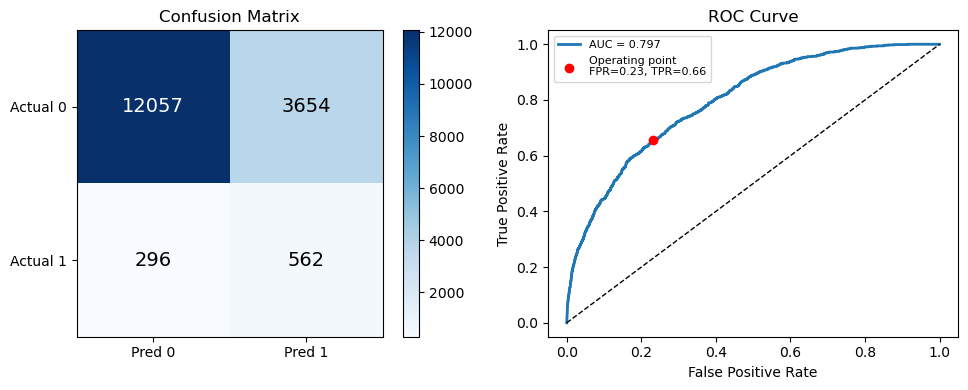

In [18]:
rf_all = RandomForestClassifier(
    n_estimators=100, max_depth=10, max_features="sqrt",
    min_samples_leaf=5, class_weight="balanced",
    random_state=42, n_jobs=-1
).fit(X_train_all_scaled, y_train_all)

y_pred = rf_all.predict(X_test_all_scaled)
y_proba = rf_all.predict_proba(X_test_all_scaled)[:, 1]

cm = confusion_matrix(y_test_all, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn); fpr = fp / (fp + tn); ppv = tp / (tp + fp)
print(f"Random Forest (all {X_all.shape[1]} features, with missingness)")
print(f"ROC-AUC: {roc_auc_score(y_test_all, y_proba):.3f}  TPR: {tpr:.3f}  FPR: {fpr:.3f}  Precision: {ppv:.3f}")
print(classification_report(y_test_all, y_pred, target_names=['Survived', 'Died']))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1']); axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix'); plt.colorbar(im, ax=axes[0])

fpr_curve, tpr_curve, _ = roc_curve(y_test_all, y_proba)
auc = roc_auc_score(y_test_all, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [19]:
# Load Lasso-selected features (missingness version) from logistic regression notebook
keep = pd.read_csv('results/lasso_selected_features_missingness.csv', header=None)[0].tolist()
print(f"Loading with {len(keep)} Lasso-selected features")

X, y, groups = DecompensationImputed.load_data(
    sample_size=100000, icu_vitals=True,
    top_n_labs=230, top_n_drugs=954, top_n_procedures=55,
    step_hours=48, keep_features=keep, missingness_indicators=True
)
X = X[[c for c in keep if c in X.columns]]
print(f"Final feature matrix: {X.shape}")

Loading with 336 Lasso-selected features
Loading from cache: decomp_rolling_n100000_v1_l230_d954_p55_o48_pred24_s48_kf336_miss
Returning 205098 windows with 406 features. y distribution:
y
0    0.978678
1    0.021322
Name: proportion, dtype: float64
Final feature matrix: (205098, 309)


In [20]:
# 80/20 patient-level split
unique_subjects = groups.unique()
np.random.seed(42)
np.random.shuffle(unique_subjects)
split = int(0.8 * len(unique_subjects))
train_subjects = set(unique_subjects[:split])
train_mask = groups.isin(train_subjects)

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {X_train.shape} ({y_train.mean():.4%} positive)")
print(f"Test:  {X_test.shape} ({y_test.mean():.4%} positive)")

Train: (164223, 309) (2.1325% positive)
Test:  (40875, 309) (2.1309% positive)


In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Decision Tree (validation curve over max_depth)

In [22]:
param_range = [3,5,7,10,15,20,30,50,100,500]
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    X_train_scaled, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
mean_val = val_scores.mean(axis=1)
best_depth = param_range[np.argmax(mean_val)]
print("best max_depth:", best_depth)

best max_depth: 7


In [23]:
decision_tree_model = DecisionTreeClassifier(max_depth=best_depth, class_weight="balanced", random_state=42).fit(X_train_scaled, y_train)

In [24]:
y_pred  = decision_tree_model.predict(X_test_scaled)
y_proba = decision_tree_model.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn); fpr = fp / (fp + tn); tnr = tn / (tn + fp); ppv = tp / (tp + fp)
print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       26732    13272   (specificity 0.668)
  Actual 1         152      719   (sensitivity 0.825)

ROC-AUC: 0.810
              precision    recall  f1-score   support

    Survived       0.99      0.67      0.80     40004
        Died       0.05      0.83      0.10       871

    accuracy                           0.67     40875
   macro avg       0.52      0.75      0.45     40875
weighted avg       0.97      0.67      0.78     40875



## Decision Tree (unbounded depth)

In [25]:
decision_tree_max_depth = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X_train_scaled, y_train)

In [26]:
y_pred  = decision_tree_max_depth.predict(X_test_scaled)
y_proba = decision_tree_max_depth.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn); fpr = fp / (fp + tn); tnr = tn / (tn + fp); ppv = tp / (tp + fp)
print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       38432     1572   (specificity 0.961)
  Actual 1         699      172   (sensitivity 0.197)

ROC-AUC: 0.584
              precision    recall  f1-score   support

    Survived       0.98      0.96      0.97     40004
        Died       0.10      0.20      0.13       871

    accuracy                           0.94     40875
   macro avg       0.54      0.58      0.55     40875
weighted avg       0.96      0.94      0.95     40875



## Random Forest

In [27]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    max_features="sqrt",
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    verbose=2,
    n_jobs=-1).fit(X_train_scaled, y_train)

building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 6 of 100
building tree 5 of 100
building tree 8 of 100
building tree 7 of 100
building tree 9 of 100
building tree 12 of 100
building tree 10 of 100
building tree 11 of 100
building tree 1 of 100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.8s


building tree 37 of 100building tree 38 of 100

building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    3.6s finished


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


Confusion matrix:
                Pred 0   Pred 1
  Actual 0       32232     7772   (specificity 0.806)
  Actual 1         231      640   (sensitivity 0.735)

TPR: 0.735  FPR: 0.194  Precision: 0.076  ROC-AUC: 0.868
              precision    recall  f1-score   support

    Survived       0.99      0.81      0.89     40004
        Died       0.08      0.73      0.14       871

    accuracy                           0.80     40875
   macro avg       0.53      0.77      0.51     40875
weighted avg       0.97      0.80      0.87     40875



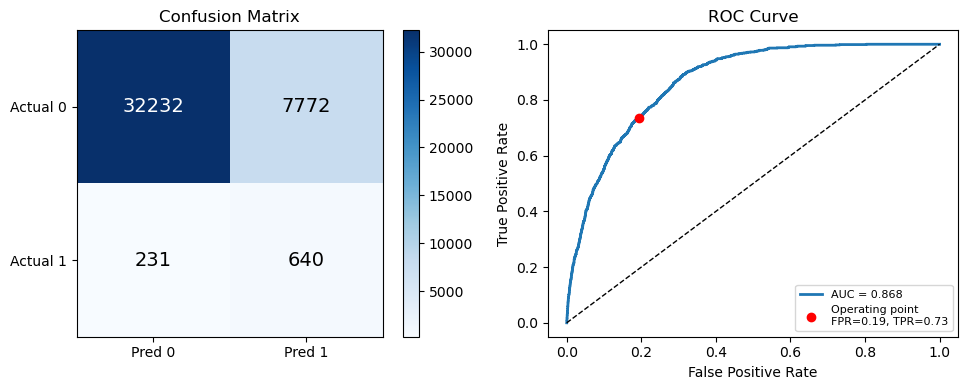

In [28]:
y_pred  = random_forest.predict(X_test_scaled)
y_proba = random_forest.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn); fpr = fp / (fp + tn); tnr = tn / (tn + fp); ppv = tp / (tp + fp)
print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print(f"\nTPR: {tpr:.3f}  FPR: {fpr:.3f}  Precision: {ppv:.3f}  ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1']); axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix'); plt.colorbar(im, ax=axes[0])

fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## AdaBoost

In [29]:
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, class_weight="balanced"),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
)
adaboost.fit(X_train_scaled, y_train)


KeyboardInterrupt


KeyboardInterrupt



In [ ]:
y_pred  = adaboost.predict(X_test_scaled)
y_proba = adaboost.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn); fpr = fp / (fp + tn); tnr = tn / (tn + fp); ppv = tp / (tp + fp)
print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print(f"\nTPR: {tpr:.3f}  FPR: {fpr:.3f}  Precision: {ppv:.3f}  ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1']); axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix'); plt.colorbar(im, ax=axes[0])

fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
clf = RandomForestClassifier(n_jobs=-1, random_state=42)

param_dist = {
    "n_estimators": [50, 100, 200, 500, 1000],
    "max_depth": [3, 5, 20, 30, None],
    "max_features": ["sqrt", 0.2, 0.5],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 10, 20, 50],
    "bootstrap": [True],
}

rs = RandomizedSearchCV(clf, param_dist, n_iter=100, cv=5, scoring="roc_auc", n_jobs=-1, random_state=42)
rs.fit(X_train, y_train)
print(rs.best_params_)